In [ ]:
import numpy as np
import pandas as pd

from model_ranking import load_transfer_metric_results
from model_ranking import plot_performance_vs_transfer_metric

In [14]:
path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria/transfer_metric_results/combined_finetuned/finetuned_combined_GBC.json"

results = load_transfer_metric_results(path)
scores = results["transfer_scores"]
performance_scores = results["performance_scores"]
correlation_scores = results["correlation_scores"]

Loaded Transfer metric results from: /scratch/talks/sampled_features/semantic_segmentation/mitochondria/transfer_metric_results/combined_finetuned/finetuned_combined_GBC.json
Experiment: finetuned_combined_GBC
Targets: 4 (EPFL, Hmito, Rmito, VNC)
Source models: 45
Total transfers: 45


Target: EPFL


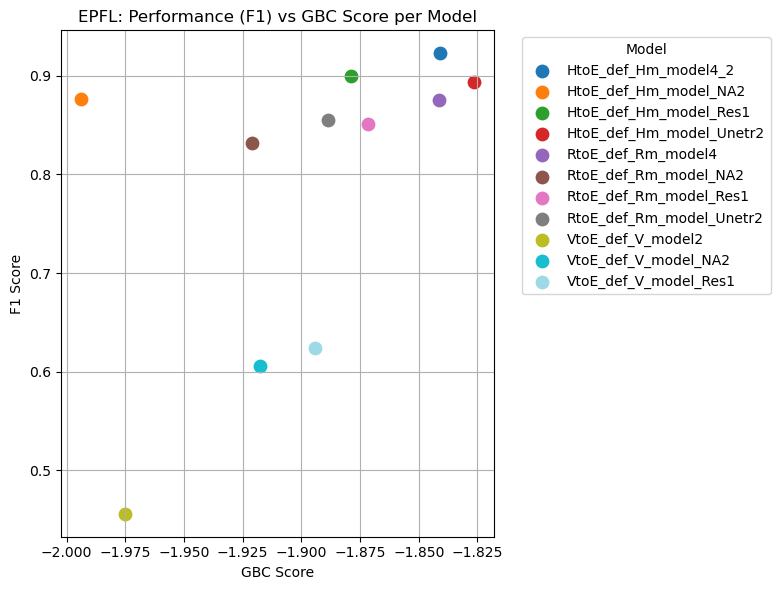

Target: Hmito


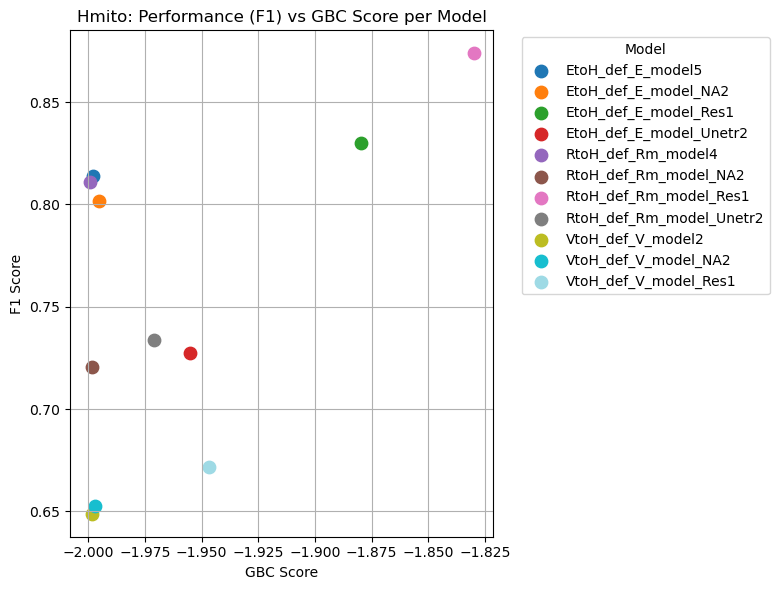

Target: Rmito


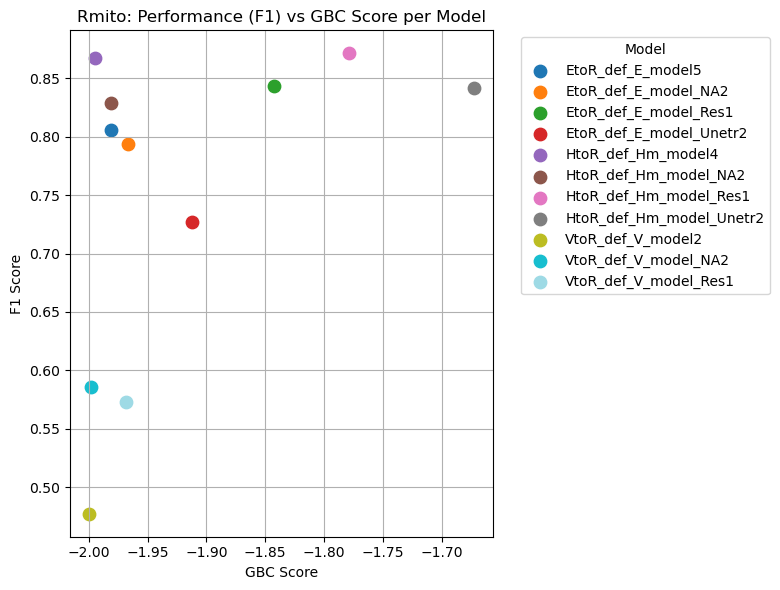

Target: VNC


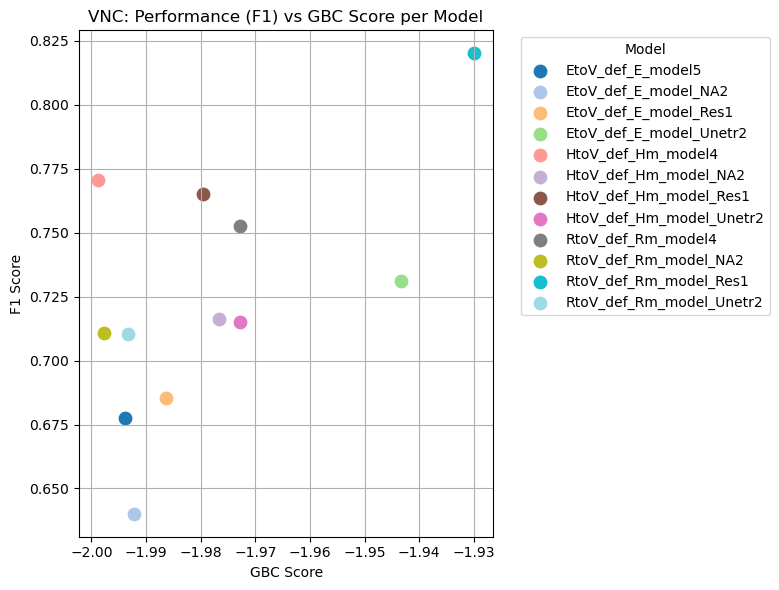

In [15]:
for target, scores_per_model in scores.items():
    print(f"Target: {target}")
    _ = plot_performance_vs_transfer_metric(performance_scores[target], scores_per_model, target=target)

In [16]:
idx = 0
per_target_KT = np.array(correlation_scores["KT"])
per_target_SP = np.array(correlation_scores["SP"])
per_target_PE = np.array(correlation_scores["PE"])
df = pd.DataFrame(
    {
        "kt": per_target_KT[:, idx, 0], 
        "kt pval": per_target_KT[:, idx, 1], 
        "s rho": per_target_SP[:, idx, 0], 
        "s rho pval": per_target_SP[:, idx, 1], 
        "pr": per_target_PE[:, idx, 0], 
        "pr pval": per_target_PE[:, idx, 1]
    },
)
df["targets"] = results["metadata"]["targets"]
df = df.set_index("targets")
df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
# Round all float columns to 2 significant figures
df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
print(df)

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.53     0.09   0.61        0.05  0.49     0.05
     Hmito    0.54     0.09   0.40        0.19  0.27     0.22
     Rmito    0.48     0.14   0.52        0.12  0.35     0.18
     VNC      0.58     0.05   0.43        0.19  0.30     0.20
